In [66]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Union
import math #for factorial (computing normalizing constant)

# Beta Distribution
### CA2 @ EPS Course

#### Instructors: Dr. Tavassolipour, Dr. Vahabie

---

### Instructions:
-  Replace the placeholders (between <font color="green">`## TODO ##`</font> and <font color="green">`## TODO ##`</font>) with the appropriate details.
- Ensure you run each cell after you've entered your solution.

---

*Full Name:* Amirmohammad Mirhosseini

*SID:* 810102601

The objective of this notebook is to estimate the probability of getting tails in a coin flip using a Bayesian approach.



In [67]:
class BetaDistribution:
    """
    Represents a beta distribution with the given shape parameters.
    """

    def __init__(self, alpha: float, beta: float):
        """
        Args:
            alpha (float): The first shape parameter of the beta distribution.
            beta (float): The second shape parameter of the beta distribution.
        """

        ######################  TODO  ########################
             
        self.alpha = alpha  
        self.beta = beta  
        c = self.__calculate_normalization_constant() 
        self.normalization_constant = c 

        ######################  TODO  ########################

    def pdf(self, x: Union[float, np.ndarray]) -> Union[float, np.ndarray]:
        """
        Calculates the normalized probability density function (PDF) of the beta distribution at the given input value(s).
        Args:
            x (float or np.ndarray): The input value(s) to evaluate the beta distribution PDF at.
        Returns:
            pdf (float or np.ndarray): The normalized probability density function evaluated at the input value(s).
        """
        ######################  TODO  ########################
        x = np.asarray(x)
        return self.__unnormalized_pdf(x) / self.normalization_constant
        ######################  TODO  ########################

    def __unnormalized_pdf(self, x: Union[float, np.ndarray]) -> Union[float, np.ndarray]:
        """
        Calculates the unnormalized probability density function (PDF) of the beta distribution at the given input value(s).

        Args:
            x (float or np.ndarray): The input value(s) to evaluate the unnormalized beta distribution PDF at.

        Returns:
            p   df (float or np.ndarray): The unnormalized probability density function evaluated at the input value(s).
        """
        ######################  TODO  ########################
        return (x ** (self.alpha - 1)) * ((1 - x) ** (self.beta - 1))
        ######################  TODO  ########################

    def __calculate_normalization_constant(self):
        """
        Calculates the normalization constant for the beta distribution.
        This constant is used to ensure that the total probability under the PDF is 1.
        """
        ######################  TODO  ########################
        # Proceed with the numerical approach
        alpha_factorial = math.factorial(self.alpha - 1)
        beta_factorial = math.factorial(self.beta - 1)
        alpha_beta_factorial = math.factorial(self.alpha + self.beta - 1)
        result = alpha_factorial * beta_factorial / alpha_beta_factorial
        return result   
        ######################  TODO  ########################

In [68]:
def plot_beta_dist(beta: BetaDistribution):
    """
    Plots the probability density function of the given beta distribution.
    
    Args:
        beta (BetaDistribution): The beta distribution instance to plot.
    """
    ######################  TODO  ########################
    # Do not forget to add title, labels, and legend.
    Xs = [i/1000 for i in range(1001)]
    Ys = beta.pdf(Xs)
  #  plt.figure(figsize=(12, 8))
    plt.plot(Xs, Ys, label=f'Beta Distribution (alpha={beta.alpha}, beta={beta.beta})', color='darkred')
   # plt.title('Beta Distribution PDF')
    plt.xlabel('x')
    plt.ylabel('PDF')
    plt.grid(True)
    plt.legend()
#plt.show()
    ######################  TODO  ########################

Read the `coint_flips.txt` file and plot the posterior distributions after every 50 trials for two prior probabilities:
1. Uniform distribution 
2. $Beta (4, 10)$

In [69]:
######################  TODO  ########################
# Read coin_flips.txt
filename = 'coin_flips.txt'
lines_vector = []
with open(filename, 'r') as file:
    lines_vector = file.readlines()
lines_vector = [line.strip() for line in lines_vector]
#print(lines_vector[0])
#print(len(lines_vector))
######################  TODO  ########################

## Prior: Uniform

**Hint:** use `plt.figure(figsize=(25, 20))` and `plt.subplot(4, 5, ...)`

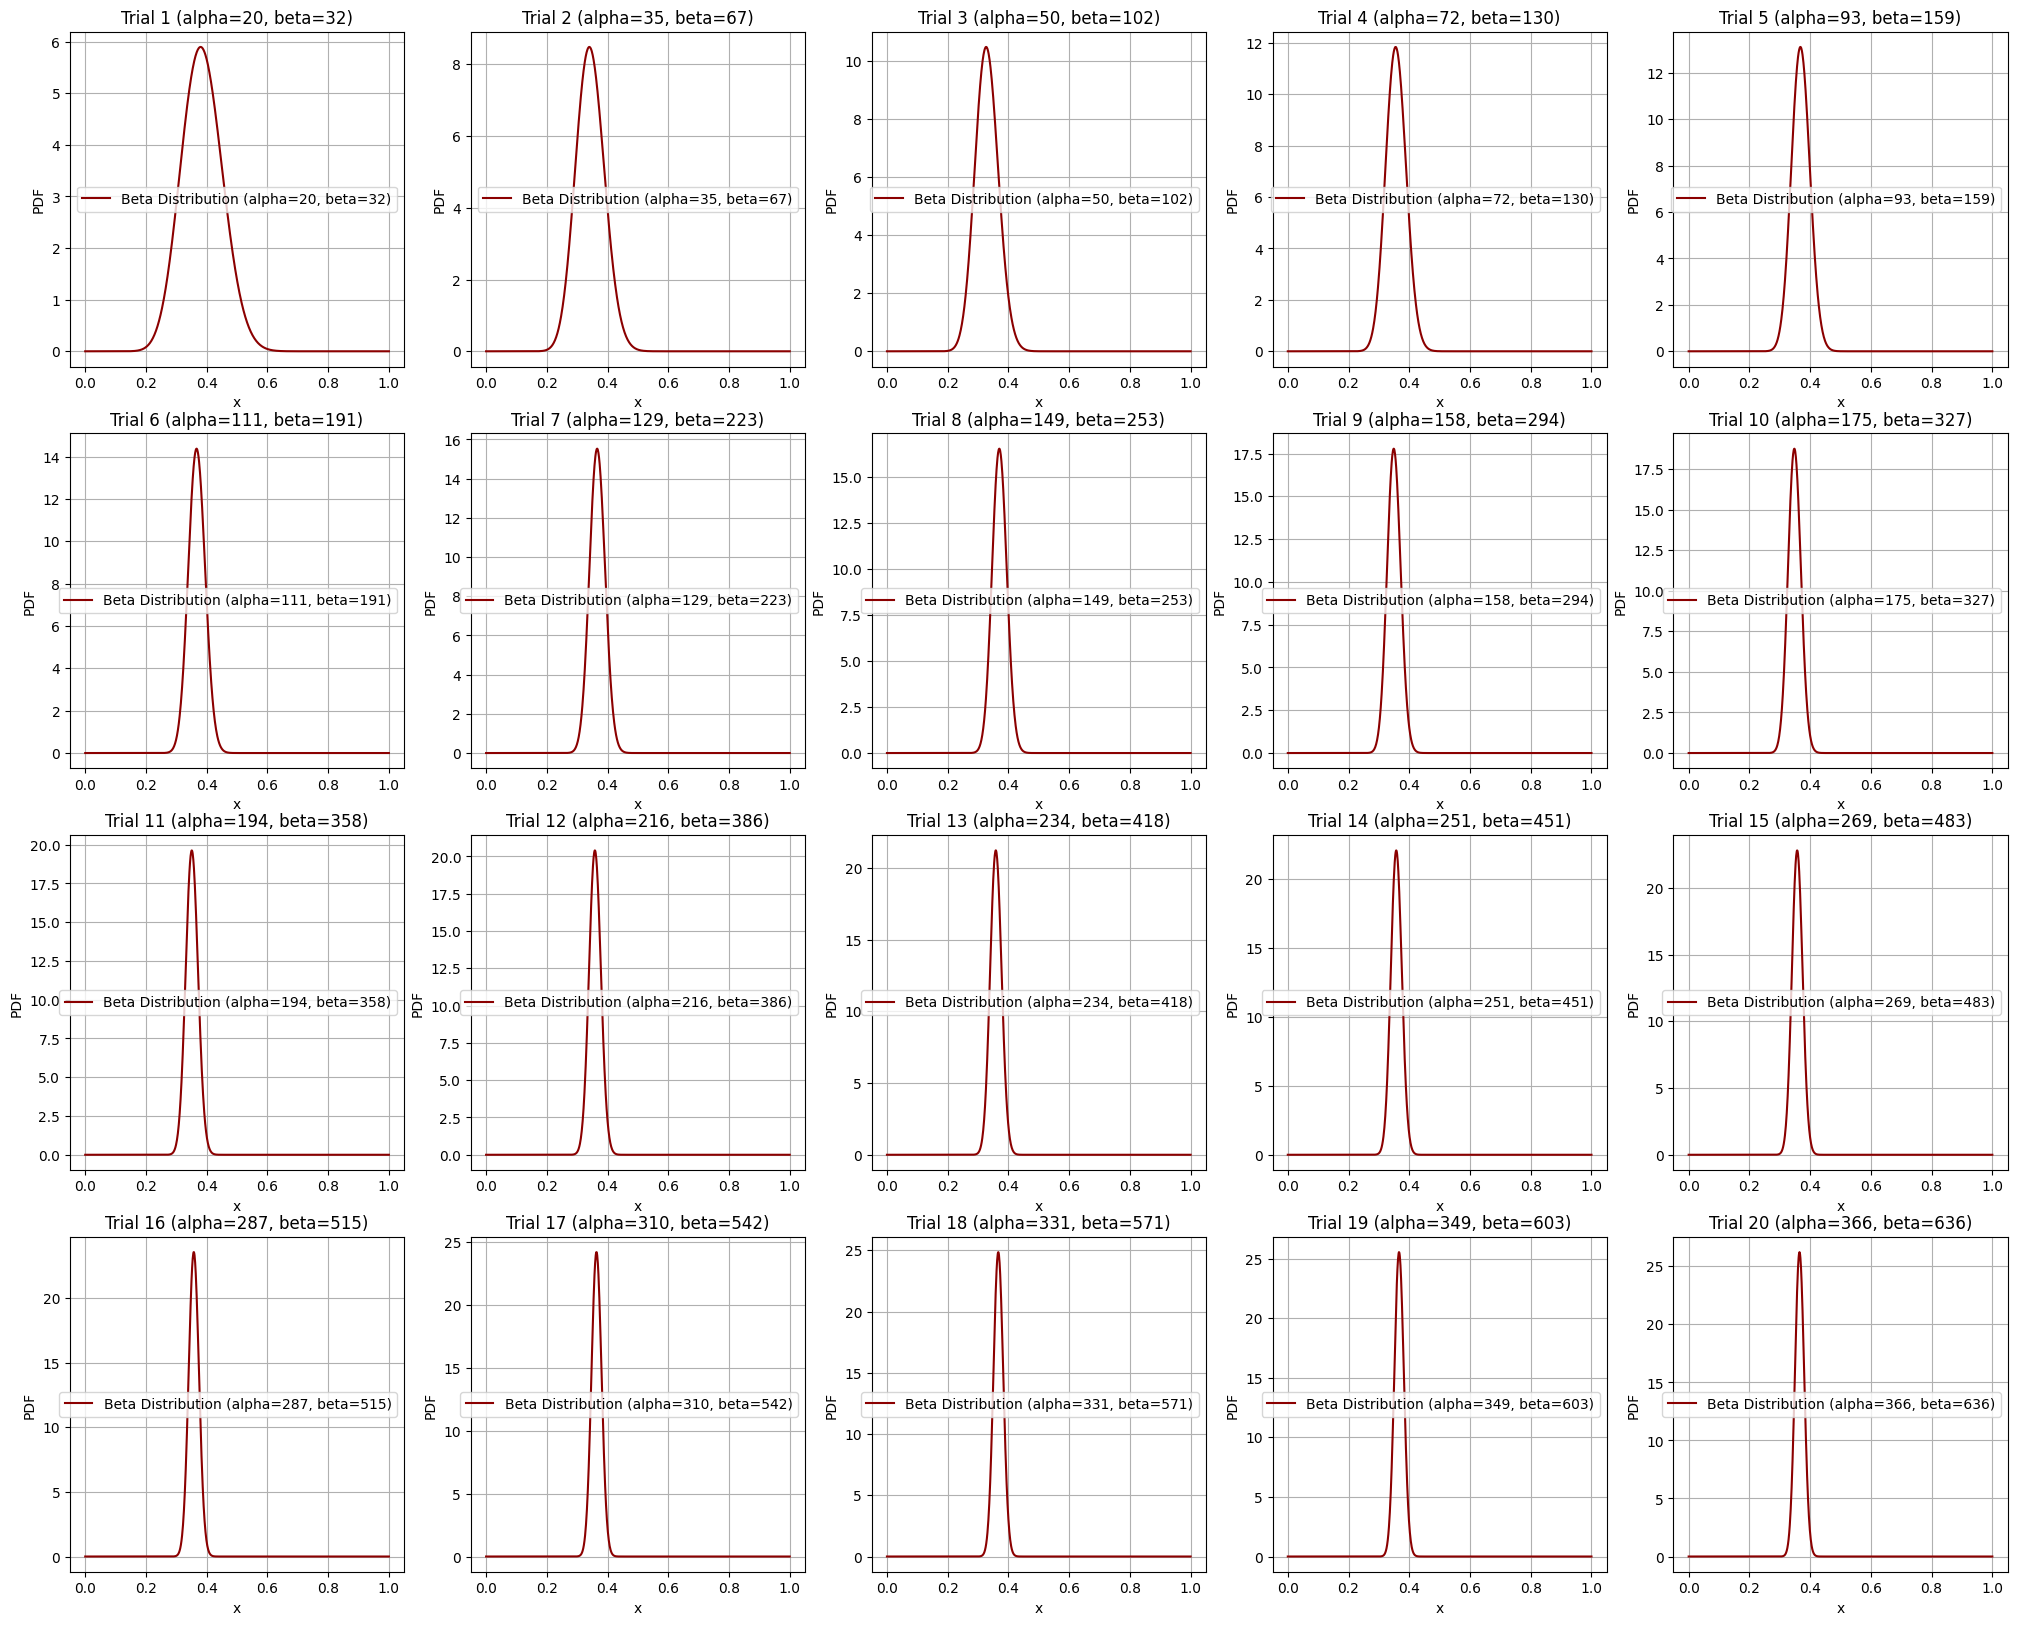

In [70]:
######################  TODO  ########################

def plot_updated_beta_distribution(trials: list):
    alpha = 1
    beta_value = 1  
    
    num_trials = 20
    trial_size = 50

    plt.figure(figsize=(25, 20))

    for i in range(num_trials):
        trial_data = trials[i * trial_size:(i + 1) * trial_size]
        heads = trial_data.count('H')
        tails = trial_data.count('T')

        alpha += heads
        beta_value += tails

        beta_dist = BetaDistribution(alpha, beta_value)

        plt.subplot(4, 5, i + 1)
        plot_beta_dist(beta_dist)
        plt.title(f'Trial {i + 1} (alpha={alpha}, beta={beta_value})')

    plt.show()


plot_updated_beta_distribution(lines_vector)

######################  TODO  ########################

Now calculate the final posterior mean and variance.

In [71]:
######################  TODO  ########################
a=366
b=636
mean1 = a/(a+b)
var1 = (a*b)/(((a+b)**2)*(a+b+1))
print('mean when Prior is Uniform is' , mean1 )
print('var when Prior is Uniform is' , var1 )
######################  TODO  ########################

mean when Prior is Uniform is 0.3652694610778443
var when Prior is Uniform is 0.00023115421922407326


## Prior: $Beta(4, 10)$

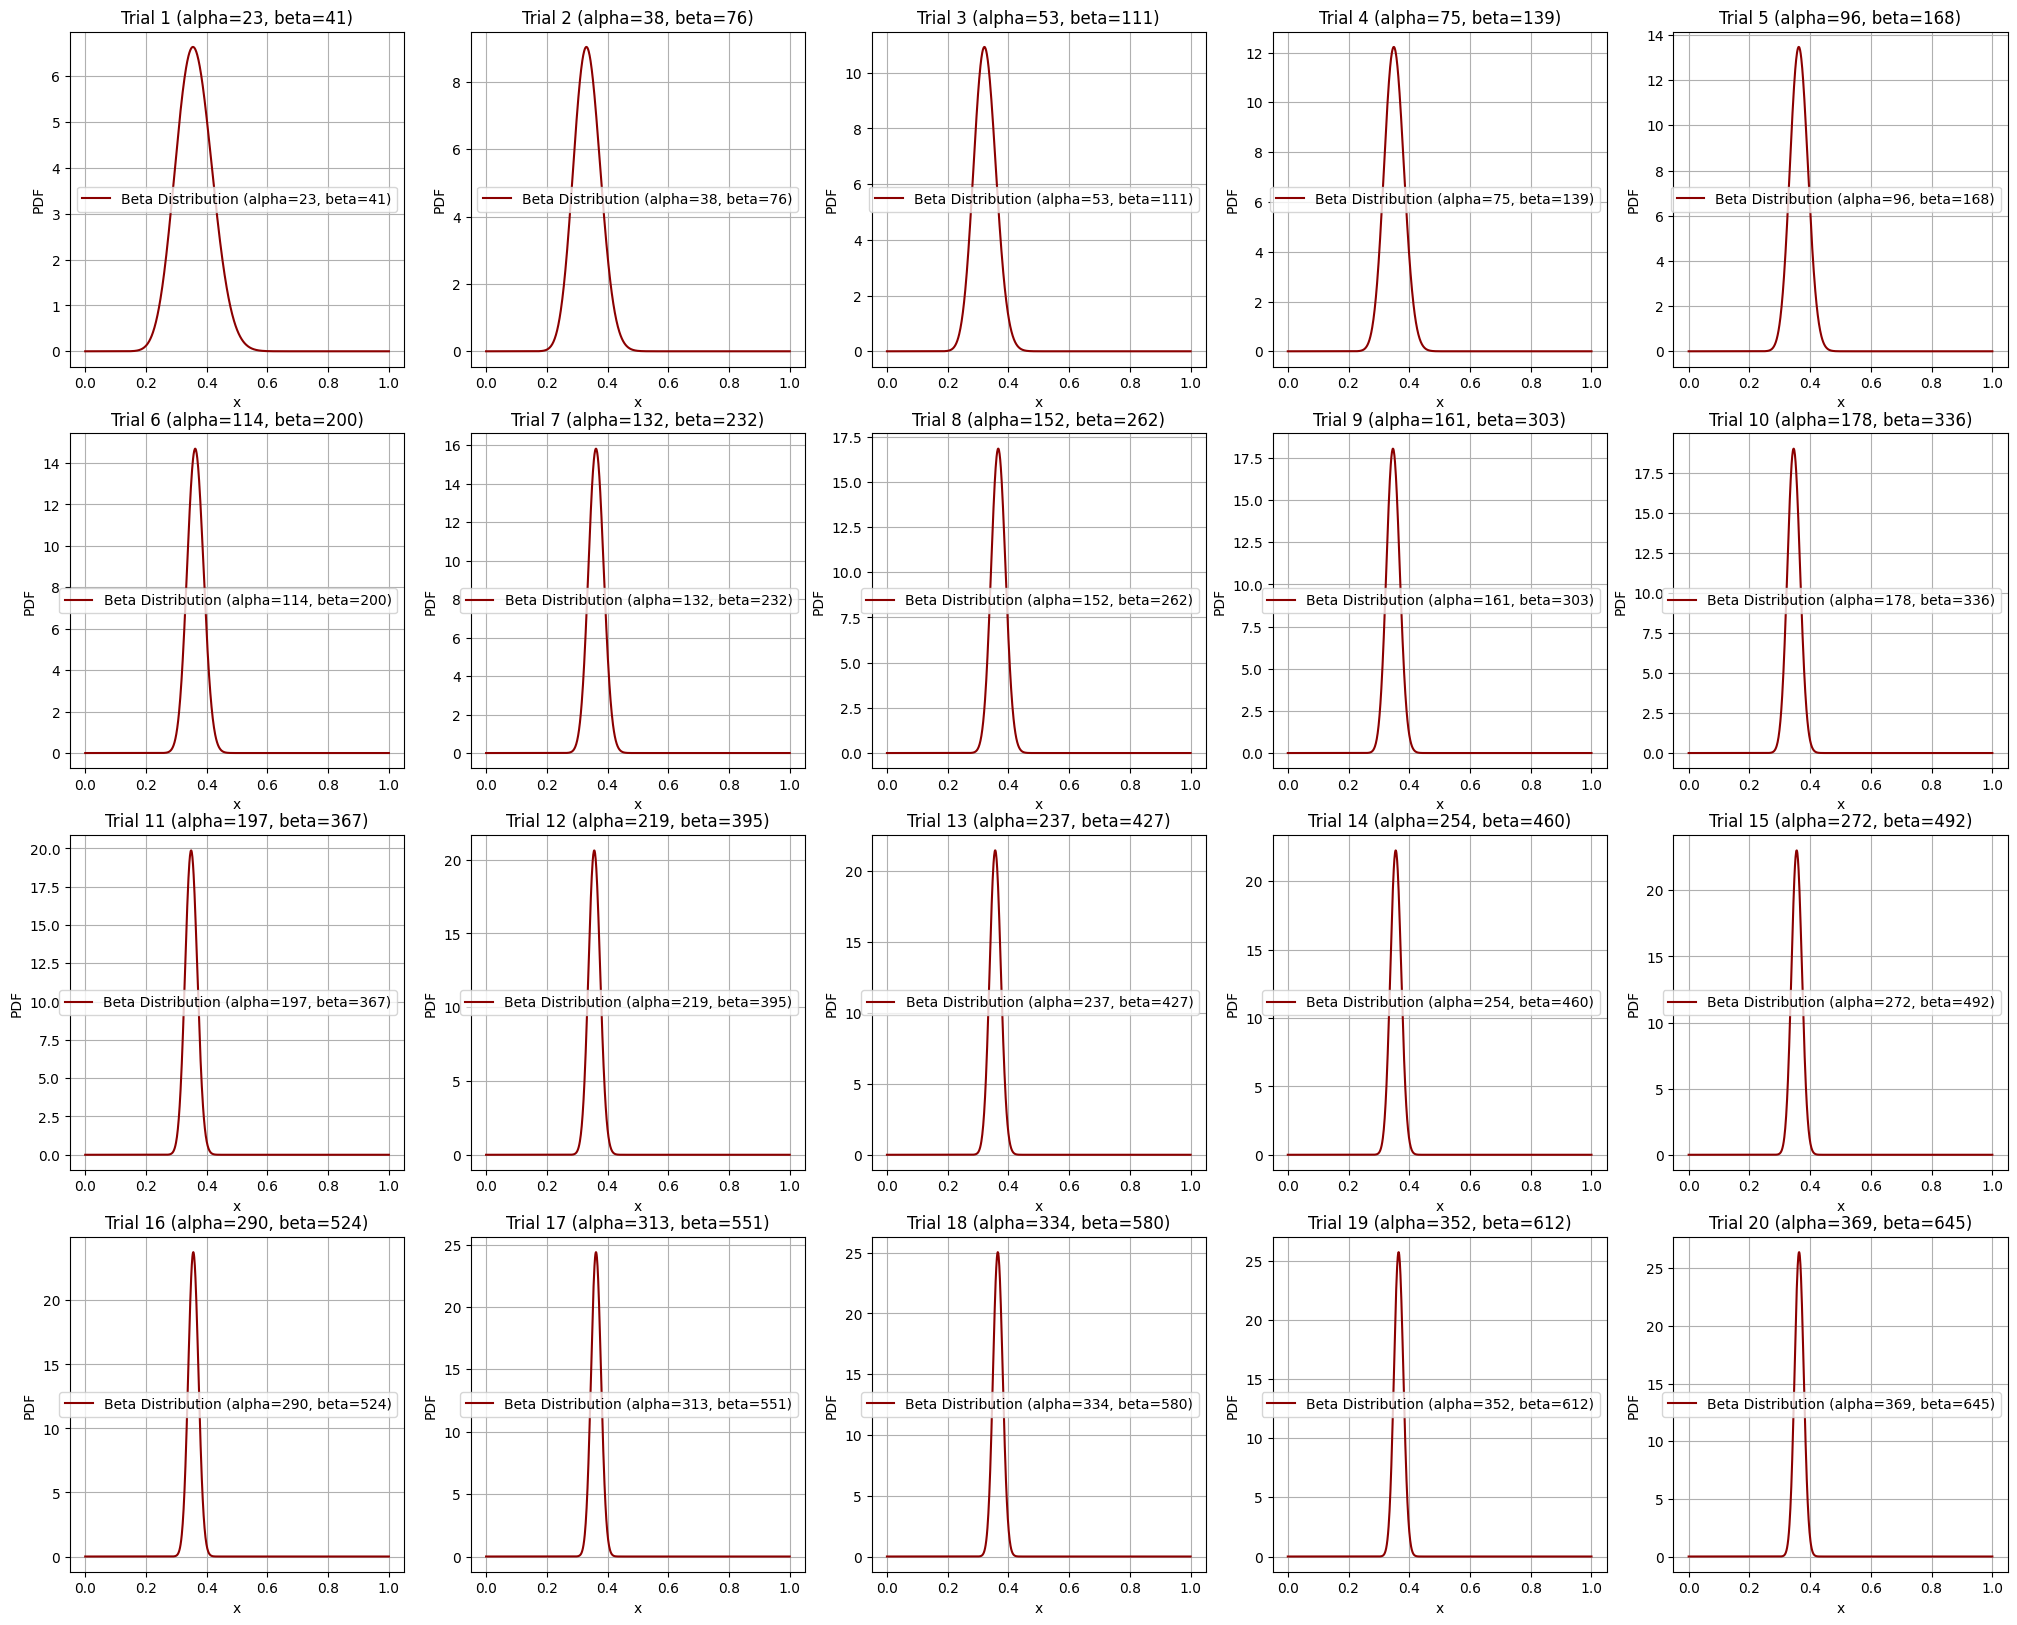

In [72]:
######################  TODO  ########################
def plot_updated_beta_distribution2(trials: list):
    alpha = 4
    beta_value = 10
    
    num_trials = 20
    trial_size = 50

    plt.figure(figsize=(25, 20))

    for i in range(num_trials):
        trial_data = trials[i * trial_size:(i + 1) * trial_size]
        heads = trial_data.count('H')
        tails = trial_data.count('T')

        alpha += heads
        beta_value += tails

        beta_dist = BetaDistribution(alpha, beta_value)

        plt.subplot(4, 5, i + 1)
        plot_beta_dist(beta_dist)
        plt.title(f'Trial {i + 1} (alpha={alpha}, beta={beta_value})')

    plt.show()


plot_updated_beta_distribution2(lines_vector)
######################  TODO  ########################

Now calculate the final posterior mean and variance.

In [73]:
######################  TODO  ########################
a2=369
b2=645
mean2 = a2/(a2+b2)
var2 = (a2*b2)/(((a2+b2)**2)*(a2+b2+1))
print('mean when Prior is Beta(4, 10) is' , mean2 )
print('var when Prior is Beta(4, 10) is' , var2 )
######################  TODO  ########################

mean when Prior is Beta(4, 10) is 0.363905325443787
var when Prior is Beta(4, 10) is 0.0002280573788743236


# توضیح مراحل
چون آلفا و بتا تعداد پرتاب سکه هست و این مقادیر صحیح می‌باشند در محاسبه ثابت نرمالایز از تابع فاکتوریل استفاده کردم نه گاما. برای حالت یونیفورم الفا و بتای اولیه را یک و یک گذاشتم و ۵۰ تا ۵۰ تا از ارایه ای که رو یا پشت بودن سکه را استخراج کرده توزیع را اپدیت کردم و با استفاده از توابع کلاس توزیع بتا ، تابع  توزیع چگالی را محاسبه و نمودار آن را رسم کردم. و این را ۲۰ بار تکرار کردم چون هزار داده داشتیم و ۵۰ داده در هر آزمایش. پس ۲۰ نمودار خواهیم داشت. توزیع آپدیت شده یعنی توان آلفا و بتا بعد از هر ترایال ذخیره شده و مساوی مقدار اولیه بعلاوه تعداد رو و پشت برای الفا و  بتای آن ترایال و ترایال های قبلی می‌باشد. درمورد توضیح کلاس توزیع بتا هم برای تابع پی دی اف نرمالایزه نشده هم از فرمول اصلی توزیع بتا استفاده کردم که هر ایکس بین ۰ و ۱ را حساب می‌کند البته چون مقدار پیوسته در برنامه نویسی ممکن نبود مقادیر ایکس با فواصل یک هزارم یک هزارم تعریف شد و این تابع به صورت المنت وایز برای هر ایکس محاسبه کرده و تابع را بدست می آورد. تابع پی دی اف نرمالایز شده هم از تقسیم پی دی اف غیر نرمالایز شده بر ثابت نرمالایز بدست می‌اید

## تحلیل:
در تعداد آزمایش پرتاب بالا بتا با مقادیر آلفا و بتای اولیه تاثیر کمی بر روی نتیجه گذاشته و پاسخ به پاسخ فرکانسی نزدیکتر است.
برای همین دو نمودار آخر تقریبا کاملا عین هم هستند.

در تعداد آزمایش پایین ، نمودار ترایال اول، تاثیر آلفا و بتای اولیه مشهود است و پاسخ به تابع بتا اولیه نزدیکتر است. هرچند چون تعداد پرتاب هر ترایال ۵۰ تا است و مقدار بالایی است کمی تشخیص این مورد سخت می‌باشد.

